In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import datetime

In [50]:
data = pd.read_csv("us-counties.csv", delimiter=',')
data

,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061.0,1,0.0
1,2020-01-22,Snohomish,Washington,53061.0,1,0.0
2,2020-01-23,Snohomish,Washington,53061.0,1,0.0
3,2020-01-24,Cook,Illinois,17031.0,1,0.0
4,2020-01-24,Snohomish,Washington,53061.0,1,0.0
...,...,...,...,...,...,...
2502827,2022-05-13,Sweetwater,Wyoming,56037.0,11088,126.0
2502828,2022-05-13,Teton,Wyoming,56039.0,10074,16.0
2502829,2022-05-13,Uinta,Wyoming,56041.0,5643,39.0
2502830,2022-05-13,Washakie,Wyoming,56043.0,2358,44.0


In [ ]:
# Get data for Cook County in Illinois (Chicago)
queer_areas = {
    "san_francisco": {
        "county": "San Francisco",
        "state": "California"
        "neighboring_counties": {
            "Snohomish County, Washington, Kitsap County, Kittitas County, Yakima County, Pierce County, and Chelan County"
        }
    },
    "portland": {
        "county": "Multnomah",
        "state": "Oregon"
    },
    "seattle": {
        "county": "King",
        "state": "Washington"
    }
}

start_date = pd.to_datetime("2020-03-10")
end_date = pd.to_datetime("2022-03-10")
weekly_dates = pd.date_range(start=start_date, end=end_date, freq='W') - pd.DateOffset(days=5) # subtract 5 days to get to weekday of 3/10/2020; Tuesday

for area, info in queer_areas.items():
    # print(info['county'], info['state'])
    area_data = data[(data['county'] == info['county']) & (data['state'] == info['state'])]
    area_data['date'] = pd.to_datetime(area_data['date'])
    area_data = area_data[(area_data['date'] >= start_date) & (area_data['date'] <= end_date)]
    area_data['delta_cases'] = area_data['cases'].diff().fillna(0)
    weekly_area_data = area_data[area_data['date'].isin(weekly_dates)]
    weekly_area_data['delta_cases'] = weekly_area_data['cases'].diff().fillna(0)
    if not os.path.exists(f"queer_areas/{area}"):
        os.mkdir(f"queer_areas/{area}")
    area_data.to_csv(f"queer_areas/{area}/{area}_daily.csv", index=False)
    weekly_area_data.to_csv(f"queer_areas/{area}/{area}_weekly.csv", index=False)
# data[(data['county'] == 'Cook County') & (data['state'] == 'IL')]

C:\Users\cgera\AppData\Local\Temp\ipykernel_25224\3318988290.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  area_data['date'] = pd.to_datetime(area_data['date'])
C:\Users\cgera\AppData\Local\Temp\ipykernel_25224\3318988290.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weekly_area_data['delta_cases'] = weekly_area_data['cases'].diff().fillna(0)
C:\Users\cgera\AppData\Local\Temp\ipykernel_25224\3318988290.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [80]:
def plot_cases_over_time(area, info, weekly: bool=False):
    data_sample = "daily"
    if weekly:
        data_sample = "weekly"
        
    area_data = pd.read_csv(f"queer_areas/{area}/{area}_{data_sample}.csv", delimiter=',')
    area_data['date'] = pd.to_datetime(area_data['date'])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(area_data['date'], area_data['delta_cases'])
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2020', etc.
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{data_sample.capitalize()} new COVID Cases")
    ax.set_title(f"{data_sample.capitalize()} new COVID Cases for {info['county']} County, {info['state']}")
    plt.savefig(f"queer_areas/{area}/new_cases_{area}_{data_sample}.png")

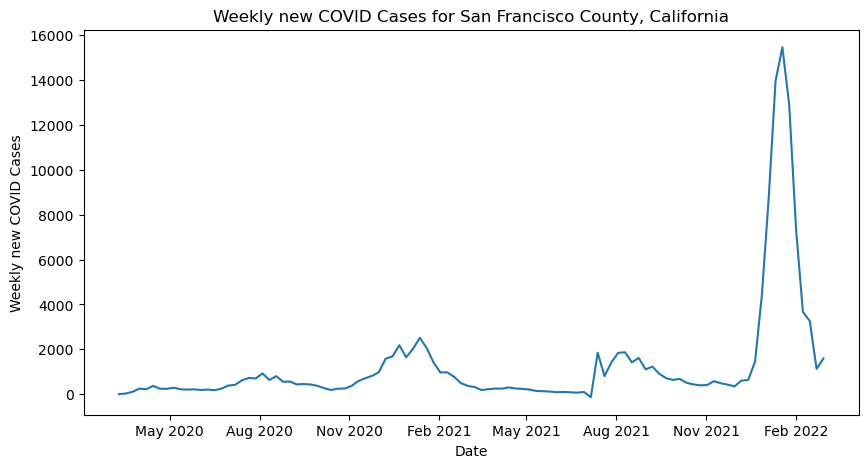

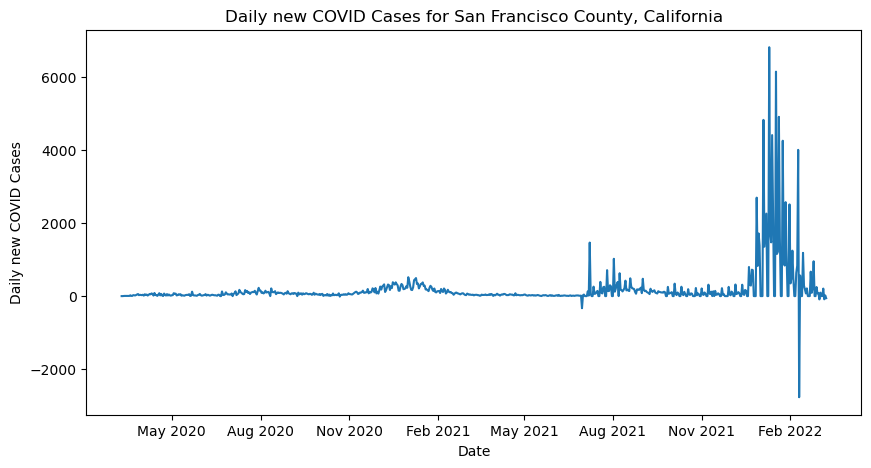

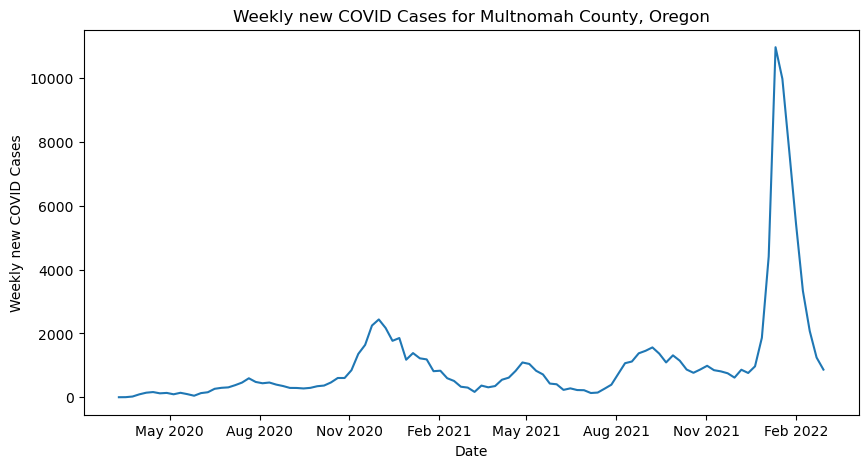

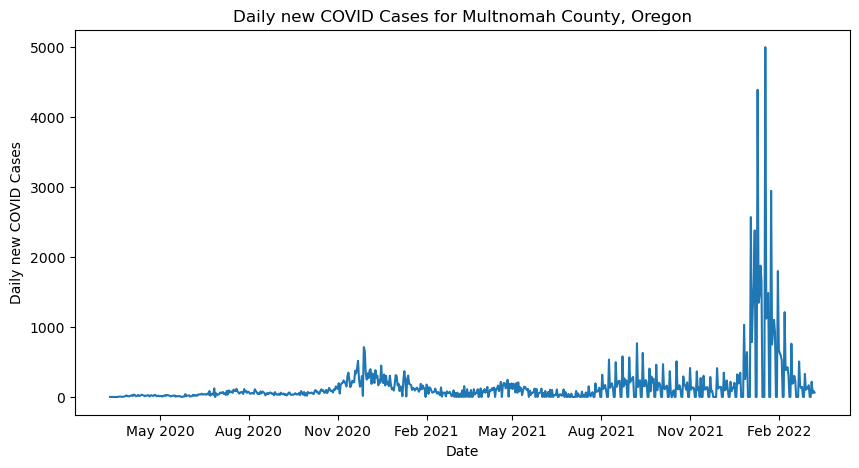

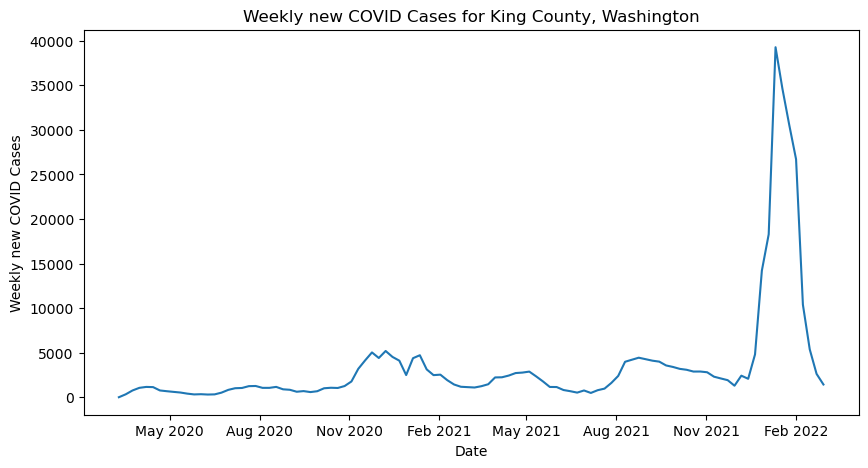

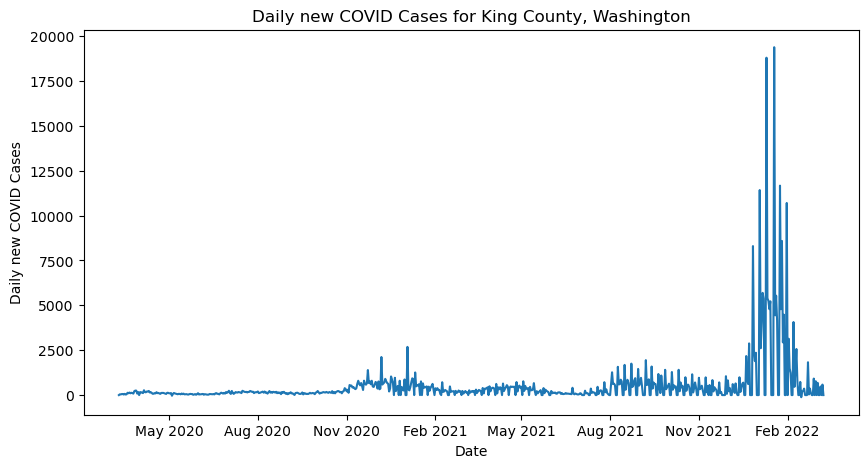

In [ ]:

for area, info in queer_areas.items():
    for weekly in [False, True]:
        plot_cases_over_time(area, info, weekly)